In [1]:
# 导入必要的库
import xarray as xr
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units
from pathlib import Path
import os, gc
import matplotlib.pyplot as plt
# 设置路径
data_path = Path('/work/mh1498/m301257/3D_data')
output_dir = Path('/work/mh1498/m301257/Plot_data/fig12/')
output_dir.mkdir(exist_ok=True, parents=True)

# 物理常数
G = 9.81  # m/s²
TROPICAL_BOUNDS = (-16, 16)  # 热带区域纬度范围

print("✓ 库导入完成")
print(f"✓ 输出目录: {output_dir}")

✓ 库导入完成
✓ 输出目录: /work/mh1498/m301257/Plot_data/fig12


## 1. 数据读取

In [2]:
print("读取数据...")
chunksize=500
# 温度数据
hus_cntl = xr.open_dataset(data_path / 'cntl/hus_all_levels.nc', chunks={'time': chunksize})['hus']
hus_p4k = xr.open_dataset(data_path / 'p4k/hus_all_levels.nc', chunks={'time': chunksize})['hus']
hus_4co2 = xr.open_dataset(data_path / '4co2/hus_all_levels.nc', chunks={'time': chunksize})['hus']

# 位势高度数据
zg_cntl = xr.open_dataset(data_path / 'zg_2deg_interp_cntl.nc', chunks={'time': chunksize})['zg']
zg_p4k = xr.open_dataset(data_path / 'zg_2deg_interp_p4k.nc', chunks={'time': chunksize})['zg']
zg_4co2 = xr.open_dataset(data_path / 'zg_2deg_interp_4co2.nc', chunks={'time': chunksize})['zg']

# 压力数据
pre_cntl = xr.open_dataset(data_path / 'cntl/pfull_all_levels.nc', chunks={'time': chunksize})['pfull']
pre_p4k = xr.open_dataset(data_path / 'p4k/pfull_all_levels.nc', chunks={'time': chunksize})['pfull']
pre_4co2 = xr.open_dataset(data_path / '4co2/pfull_all_levels.nc', chunks={'time': chunksize})['pfull']

print(f"✓ 数据读取完成")
print(f"  q数据维度: {hus_cntl.dims}")
print(f"  高度数据维度: {zg_cntl.dims}")
print(f"  压力数据维度: {pre_cntl.dims}")

读取数据...
✓ 数据读取完成
  q数据维度: ('level', 'time', 'lat', 'lon')
  高度数据维度: ('level_full', 'lat', 'lon')
  压力数据维度: ('level', 'time', 'lat', 'lon')


## 2. 数据预处理 - 热带海洋平均

✓ 维度名称: lat=lat, lon=lon, lev=level, time=time

数据维度检查:
  hus_cntl:  ('level', 'time', 'lat', 'lon')
  pre_cntl: ('level', 'time', 'lat', 'lon')
  zg_cntl:  ('level_full', 'lat', 'lon')

✓ 海洋掩膜加载完成: (15, 180)

应用热带海洋掩膜...
✓ 热带海洋区域选择完成
  q 形状:  (22, 5114, 15, 180)
  pre 形状: (22, 5114, 15, 180)
  zg 形状:  (22, 15, 180)


31

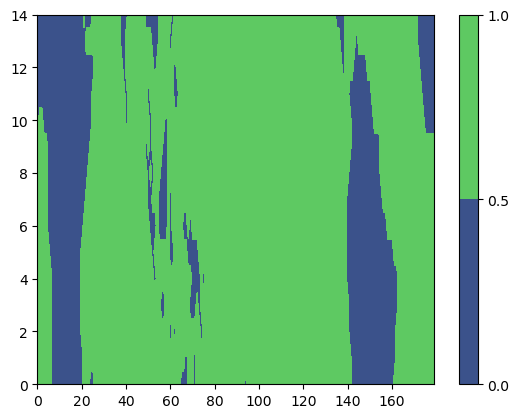

In [3]:
# 检测维度名称
def detect_dims(da):
    """自动检测数据维度名称"""
    lat_dim = [d for d in da.dims if d in ['lat', 'latitude', 'LAT']][0]
    lon_dim = [d for d in da.dims if d in ['lon', 'longitude', 'LON']][0]
    lev_dim = [d for d in da.dims if 'lev' in d.lower()][0]
    time_dim = [d for d in da.dims if 'time' in d.lower()]
    time_dim = time_dim[0] if time_dim else None
    return lat_dim, lon_dim, lev_dim, time_dim

lat_dim, lon_dim, lev_dim, time_dim = detect_dims(hus_cntl)
print(f"✓ 维度名称: lat={lat_dim}, lon={lon_dim}, lev={lev_dim}, time={time_dim}")

# 检查各数据集的维度
print(f"\n数据维度检查:")
print(f"  hus_cntl:  {hus_cntl.dims}")
print(f"  pre_cntl: {pre_cntl.dims}")
print(f"  zg_cntl:  {zg_cntl.dims}")

# 读取海洋掩膜
def load_ocean_mask():
    land_mask = xr.open_dataset('/work/mh1498/m301257/Plot_data/fig07/ocean_mask_2deg.nc')
    ocean_mask = land_mask['__xarray_dataarray_variable__'] == 1  # 海洋为True
    return ocean_mask

ocean_mask = load_ocean_mask()
plt.contourf(ocean_mask)  
plt.colorbar()  
print(f"\n✓ 海洋掩膜加载完成: {ocean_mask.shape}")

# 热带区域选择和掩膜应用
def select_tropical_ocean(da, lat_dim_name, ocean_mask_2d):
    """选择热带海洋区域"""
    # 选择热带纬度
    da_tropical = da.sel({lat_dim_name: slice(*TROPICAL_BOUNDS)})
    # 应用海洋掩膜 - 确保掩膜的维度顺序匹配
    # 掩膜只有 (lat, lon)，需要广播到数据的维度
    da_tropical = da_tropical.where(ocean_mask_2d)
    return da_tropical

print(f"\n应用热带海洋掩膜...")
hus_cntl_ocean = select_tropical_ocean(hus_cntl, lat_dim, ocean_mask)
hus_p4k_ocean = select_tropical_ocean(hus_p4k, lat_dim, ocean_mask)
hus_4co2_ocean = select_tropical_ocean(hus_4co2, lat_dim, ocean_mask)

pre_cntl_ocean = select_tropical_ocean(pre_cntl, lat_dim, ocean_mask)
pre_p4k_ocean = select_tropical_ocean(pre_p4k, lat_dim, ocean_mask)
pre_4co2_ocean = select_tropical_ocean(pre_4co2, lat_dim, ocean_mask)

zg_cntl_ocean = select_tropical_ocean(zg_cntl, lat_dim, ocean_mask)
zg_p4k_ocean = select_tropical_ocean(zg_p4k, lat_dim, ocean_mask)
zg_4co2_ocean = select_tropical_ocean(zg_4co2, lat_dim, ocean_mask)

print(f"✓ 热带海洋区域选择完成")
print(f"  q 形状:  {hus_cntl_ocean.shape}")
print(f"  pre 形状: {pre_cntl_ocean.shape}")
print(f"  zg 形状:  {zg_cntl_ocean.shape}")
del hus_cntl, hus_p4k, hus_4co2
del pre_cntl, pre_p4k, pre_4co2
del zg_cntl, zg_p4k, zg_4co2
gc.collect()

In [4]:
hus_cntl_ocean

<xarray.DataArray 'hus' (level: 22, time: 5114, lat: 15, lon: 180)> Size: 2GB
dask.array<where, shape=(22, 5114, 15, 180), dtype=float64, chunksize=(22, 500, 15, 180), chunktype=numpy.ndarray>
Coordinates:
  * level    (level) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0

## 4. 计算干静力稳定性 (Dry Static Stability)

In [5]:
newlevel = zg_cntl_ocean.mean(['lat','lon']).values
hus_cntl_3d =   hus_cntl_ocean.assign_coords({lev_dim: newlevel})
hus_p4k_3d  =   hus_p4k_ocean.assign_coords({lev_dim: newlevel})
hus_4co2_3d =   hus_4co2_ocean.assign_coords({lev_dim: newlevel})

gc.collect()

5264

In [ ]:
# ============================================================================
# ⚠️ 关键检查: 确认高度数据的单位
# ============================================================================

print("\n" + "="*70)
print("检查高度数据 (zg) 的单位和数值范围")
print("="*70)

# 检查原始数据的属性
print("\n1. 原始 zg 数据信息:")
print(f"   变量名: zg")
if hasattr(zg_cntl_ocean, 'units'):
    print(f"   单位属性: {zg_cntl_ocean.units}")
if hasattr(zg_cntl_ocean, 'long_name'):
    print(f"   长名称: {zg_cntl_ocean.long_name}")

# 检查数值范围
zg_min = float(zg_cntl_ocean.min())
zg_max = float(zg_cntl_ocean.max())
print(f"\n2. 数值范围:")
print(f"   最小值: {zg_min:.2f}")
print(f"   最大值: {zg_max:.2f}")

# 判断单位
print(f"\n3. 单位判断:")
if zg_max > 50000:  # > 50 km 说明可能是 Pa
    print(f"   ⚠️ 警告: 数值很大({zg_max:.0f})，可能是压力单位(Pa)")
    print(f"   建议检查数据!")
elif zg_max > 100:  # > 100 说明可能是 m 或 gpm
    print(f"   ✓ 数值范围合理 (0-{zg_max:.0f})")
    if zg_max > 50000:
        print(f"   可能单位: m (米)")
    else:
        print(f"   可能单位: m 或 gpm (位势米)")
        print(f"   注: gpm 和 m 在数值上非常接近，可直接使用")
else:
    print(f"   ⚠️ 警告: 数值太小({zg_max:.2f})，请检查单位")

# 计算平均高度廓线
newlevel = zg_cntl_ocean.mean(['lat','lon']).values
print(f"\n4. 平均高度廓线 (newlevel):")
print(f"   形状: {newlevel.shape}")
print(f"   范围: {newlevel.min():.1f} - {newlevel.max():.1f}")
print(f"   底层高度: {newlevel[0]:.1f}")
print(f"   顶层高度: {newlevel[-1]:.1f}")

# 检查垂直分辨率
if len(newlevel) > 1:
    dz_typical = np.median(np.diff(newlevel))
    print(f"   典型层厚: {dz_typical:.1f}")



检查高度数据 (zg) 的单位和数值范围

1. 原始 zg 数据信息:
   变量名: zg

2. 数值范围:
   最小值: 12.50
   最大值: 22864.41

3. 单位判断:
   ✓ 数值范围合理 (0-22864)
   可能单位: m 或 gpm (位势米)
   注: gpm 和 m 在数值上非常接近，可直接使用

4. 平均高度廓线 (newlevel):
   形状: (22,)
   范围: 13.0 - 22864.4
   底层高度: 22864.4
   顶层高度: 13.0
   典型层厚: -947.7

✓ 高度数据检查完成
  将使用 newlevel 作为垂直坐标计算 dθ/dz



In [7]:
def calculate_dqdz(data, height_profile_m, lev_dim_name):
    """
    计算比湿的垂直梯度 dq/dz。
    """
    print(f"  计算比湿场平均廓线...")
    # 先对空间和时间维度求平均，得到1D廓线
    avg_dims = [d for d in data.dims if d != lev_dim_name]
    data_profile = data.mean(dim=avg_dims).compute()
    
    print(f"  计算垂直梯度...")

    dq = np.gradient(data_profile.values)
    dz = np.gradient(height_profile_m)
    dq_dz = dq / dz
    
    # 转换为 DataArray
    coords = {lev_dim_name: data_profile[lev_dim_name]}


    dq_dz_da = xr.DataArray(
        dq_dz,
        coords=coords,
        dims=[lev_dim_name],
        attrs={
            'long_name': 'specific humidity vertical gradient',
            'units': '1/m'
        }
    )
    
    return dq_dz_da

print("步骤3: 计算干静力稳定性 N²...")
print("  这一步会先计算时空平均廓线，然后计算垂直梯度...")

# 计算各个试验的静力稳定性
print("\n  处理 CNTL...")
dq_dz_cntl = calculate_dqdz(hus_cntl_3d   , newlevel, lev_dim)

print("\n  处理 P4K...")
dq_dz_p4k = calculate_dqdz(hus_p4k_3d, newlevel, lev_dim)

print("\n  处理 4CO2...")
dq_dz_4co2 = calculate_dqdz(hus_4co2_3d, newlevel, lev_dim)


步骤3: 计算干静力稳定性 N²...
  这一步会先计算时空平均廓线，然后计算垂直梯度...

  处理 CNTL...
  计算比湿场平均廓线...
  计算垂直梯度...

  处理 P4K...
  计算比湿场平均廓线...
  计算垂直梯度...

  处理 4CO2...
  计算比湿场平均廓线...
  计算垂直梯度...


In [8]:
dq_dz_cntl

<xarray.DataArray (level: 22)> Size: 176B
array([ 7.54760412e-11,  1.22604587e-10,  1.41387739e-10, -1.33323261e-09,
       -9.43654853e-09, -3.67933694e-08, -8.74319088e-08, -2.14351394e-07,
       -4.19343158e-07, -8.02453277e-07, -1.16011541e-06, -1.63562681e-06,
       -2.58436782e-06, -3.79952133e-06, -4.86581336e-06, -6.25173839e-06,
       -6.28129628e-06, -4.47063088e-06, -2.38192207e-06, -1.71543220e-06,
       -2.38055253e-06, -5.67297452e-06])
Coordinates:
  * level    (level) float64 176B 2.286e+04 1.954e+04 1.752e+04 ... 52.76 13.01
Attributes:
    long_name:  specific humidity vertical gradient
    units:      1/m

In [9]:
print("\n保存计算结果...")

# 创建数据集
ds = xr.Dataset({
    
    # 位温垂直梯度 (K/m)
    'dq_dz_cntl': dq_dz_cntl,
    'dq_dz_p4k': dq_dz_p4k,
    'dq_dz_4co2': dq_dz_4co2,
    # 高度廓线 (m)
    'height': (lev_dim, newlevel),
})

# 添加全局属性
ds.attrs = {
    'title': 'dqdz for Tropical Ocean',
    'description': 'Vertical profiles of q gradient ',
    'region': f'Tropical Ocean ({TROPICAL_BOUNDS[0]}°-{TROPICAL_BOUNDS[1]}°)',
    'method': 'specific humidity calculated at each grid point first, then averaged over tropical ocean',
    'created': str(np.datetime64('now')),
}

# 保存为NetCDF文件
output_file = output_dir / 'dqdz_data.nc'
ds.to_netcdf(output_file)




保存计算结果...
